# Full-Spectrum Splitting-Function PLI

Phase 1 — spectral inventory.

In [1]:
import sys
import os

# Ensure paper_demos directory is on the path
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt

from normal_mode_kernel_utils import NormalModeDataRegistry, NormalModeKernelCatalog
from full_spectrum_utils import BlockIndex, enumerate_blocks, block_data_split

DATA_DIR = 'data/normal-mode-data'
KERNEL_DIR = 'data/normal-mode-kernels/kernels-all_PREM-layers_Adrian'
S_MAX = 4

catalog = NormalModeKernelCatalog(KERNEL_DIR)
reg = NormalModeDataRegistry(DATA_DIR, mode_filter=catalog.list_modes())

blocks = enumerate_blocks(reg, s_max=S_MAX)
split = block_data_split(reg, blocks)

print(f'Total observations: {len(reg)}')
print(f'Blocks found (even s \u2264 {S_MAX}): {len(blocks)}')
for b in blocks:
    print(f'  BlockIndex(s={b.s}, t={b.t}): {len(split[b])} observations')

Total observations: 8210
Blocks found (even s ≤ 4): 15
  BlockIndex(s=0, t=0): 186 observations
  BlockIndex(s=2, t=0): 186 observations
  BlockIndex(s=2, t=1): 186 observations
  BlockIndex(s=2, t=2): 186 observations
  BlockIndex(s=2, t=3): 186 observations
  BlockIndex(s=2, t=4): 186 observations
  BlockIndex(s=4, t=0): 170 observations
  BlockIndex(s=4, t=1): 170 observations
  BlockIndex(s=4, t=2): 170 observations
  BlockIndex(s=4, t=3): 170 observations
  BlockIndex(s=4, t=4): 170 observations
  BlockIndex(s=4, t=5): 170 observations
  BlockIndex(s=4, t=6): 170 observations
  BlockIndex(s=4, t=7): 170 observations
  BlockIndex(s=4, t=8): 170 observations


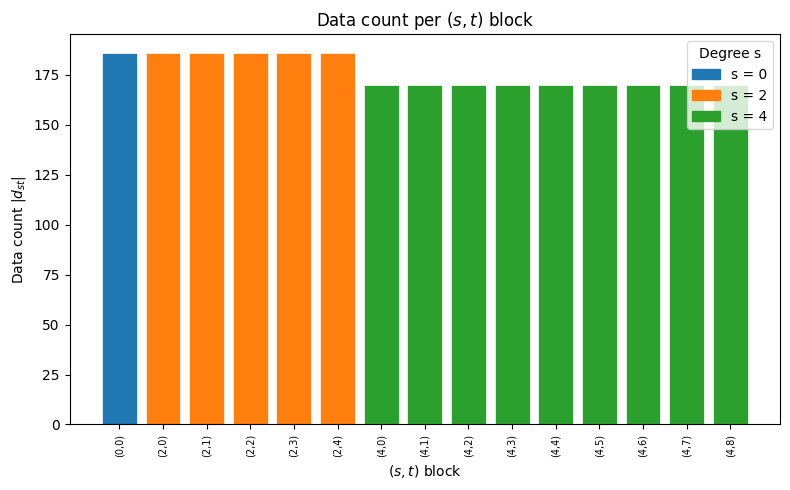

Figure saved to data_count_per_block.png


In [2]:
# Bar plot: data count |d_{st}| per (s, t) block, grouped by s-degree

s_values = sorted({b.s for b in blocks})
colors = plt.cm.tab10.colors
s_color = {s: colors[i % len(colors)] for i, s in enumerate(s_values)}

labels = [f'({b.s},{b.t})' for b in blocks]
counts = [len(split[b]) for b in blocks]
bar_colors = [s_color[b.s] for b in blocks]

fig, ax = plt.subplots(figsize=(max(8, len(blocks) * 0.35), 5))
x = np.arange(len(blocks))
ax.bar(x, counts, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_xlabel('$(s, t)$ block')
ax.set_ylabel('Data count $|d_{st}|$')
ax.set_title('Data count per $(s,t)$ block')

# Legend for s-degree
from matplotlib.patches import Patch
legend_handles = [Patch(color=s_color[s], label=f's = {s}') for s in s_values]
ax.legend(handles=legend_handles, title='Degree s', loc='upper right')

plt.tight_layout()
fig.savefig('data_count_per_block.png', dpi=150)
plt.show()
print('Figure saved to data_count_per_block.png')

## Phase 2: Per-block forward operators

In [3]:
from full_spectrum_utils import RadialSpecs, build_block_forward
from intervalinf import ParallelConfig

specs = RadialSpecs(n_basis=100, parallel_cfg=ParallelConfig(enabled=True, n_jobs=12))
forward_dict = {b: build_block_forward(b.s, b.t, split[b], catalog, specs) for b in blocks}
print(f"Built {len(forward_dict)} block forward operators")
for b, (G, C_D, M, D) in sorted(forward_dict.items()):
    print(f"  Block (s={b.s},t={b.t}): N_d={D.dim}, M.dim={M.dim}")

Built 15 block forward operators
  Block (s=0,t=0): N_d=186, M.dim=402
  Block (s=2,t=0): N_d=186, M.dim=402
  Block (s=2,t=1): N_d=186, M.dim=402
  Block (s=2,t=2): N_d=186, M.dim=402
  Block (s=2,t=3): N_d=186, M.dim=402
  Block (s=2,t=4): N_d=186, M.dim=402
  Block (s=4,t=0): N_d=170, M.dim=402
  Block (s=4,t=1): N_d=170, M.dim=402
  Block (s=4,t=2): N_d=170, M.dim=402
  Block (s=4,t=3): N_d=170, M.dim=402
  Block (s=4,t=4): N_d=170, M.dim=402
  Block (s=4,t=5): N_d=170, M.dim=402
  Block (s=4,t=6): N_d=170, M.dim=402
  Block (s=4,t=7): N_d=170, M.dim=402
  Block (s=4,t=8): N_d=170, M.dim=402


## Phase 3 — Per-block prior covariance with shared Bessel-Sobolev operators

Each radial parameter ($v_p$, $v_s^{\mathrm{IC}}$, $v_s^{\mathrm{M}}$, $\rho$) has a prior covariance
$$C_{p,st} = \tau_{p,s}^2 \, C_p^{\mathrm{ref}}$$
where $C_p^{\mathrm{ref}}$ is a Bessel-Sobolev covariance built once on a reference Lebesgue space and shared across all $(s, t)$ blocks.  The spectral amplitude $\tau_{p,s} = 1$ (flat default) can be overridden per parameter and per splitting degree.

**Note:** The geophysically correct inner product uses $w(r) = r^2$ radial weighting.  This requires radial-elliptic covariances not yet implemented in intervalinf; the flat ($w = 1$) inner product is used throughout.

In [4]:
from full_spectrum_utils import (
    build_shared_bessel_blocks,
    prior_power_spectrum_default,
    build_block_prior,
)

# Build one BesselSobolevInverse per radial parameter (shared across all blocks)
shared_bessel = build_shared_bessel_blocks(specs)
print("Shared Bessel-Sobolev operators built for:", list(shared_bessel.keys()))

# Assemble per-block prior using default flat power spectrum (tau=1 for all p, s)
prior_dict = {
    block: build_block_prior(
        block.s, block.t,
        shared_bessel, specs,
        tau_fn=prior_power_spectrum_default,
        sigma_var=100.0,
    )
    for block in blocks
}

print(f"\nBuilt {len(prior_dict)} block priors")
for block, prior in sorted(prior_dict.items()):
    dim = prior.covariance.domain.dim
    print(f"  Block (s={block.s}, t={block.t}): prior domain dim = {dim}")

Shared Bessel-Sobolev operators built for: ['vp', 'vs_IC', 'vs_M', 'rho']

Built 15 block priors
  Block (s=0, t=0): prior domain dim = 402
  Block (s=2, t=0): prior domain dim = 402
  Block (s=2, t=1): prior domain dim = 402
  Block (s=2, t=2): prior domain dim = 402
  Block (s=2, t=3): prior domain dim = 402
  Block (s=2, t=4): prior domain dim = 402
  Block (s=4, t=0): prior domain dim = 402
  Block (s=4, t=1): prior domain dim = 402
  Block (s=4, t=2): prior domain dim = 402
  Block (s=4, t=3): prior domain dim = 402
  Block (s=4, t=4): prior domain dim = 402
  Block (s=4, t=5): prior domain dim = 402
  Block (s=4, t=6): prior domain dim = 402
  Block (s=4, t=7): prior domain dim = 402
  Block (s=4, t=8): prior domain dim = 402
